# University Physics with Modern Physics

<img src="..//pics/cover.png" width=400> 



In [1]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1


<IPython.core.display.Javascript object>

All imports succeeded!


In [2]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec


In [3]:
!python --version

Python 3.12.10


In [4]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_University_Physics_Young_15\\ch02'

# 2 Motion Along a Stright Line

## PROBLEMS Section 

### CHALLENGE PROBLEMS




#### 2.87 
page 92

••• In the vertical jump, an athlete starts from a crouch and
jumps upward as high as possible. Even the best athletes spend little
more than 1.00 s in the air (their “hang time”). Treat the athlete as a
particle and let $y_{max}$ be his maximum height above the floor. To explain
why he seems to hang in the air, calculate the ratio of the time he is
above $y_{max}>2$ to the time it takes him to go from the floor to that height.
Ignore air resistance.

In [ ]:
# --- 1. Define Symbolic Variables ---
v0, g, t, t_up, ymax = sp.symbols("v0 g t t_up y_max", real=True, positive=True)

# Kinematic equations
# from the eq: v^2 = v0^2 - 2 g y (at apex v=0)
eq_vel_sq = sp.Eq(0, v0**2 - 2 * g * ymax)
ymax_expr = sp.solve(eq_vel_sq, ymax)[0]

# from the eq: a = v / t
eq_accel = sp.Eq(g, v0 / t_up)
t_up_expr = sp.solve(eq_accel, t_up)[0]

# --- 2. Solve for Times at y = y_max / 2 ---
y_half_expr = ymax_expr / 2
eq_y_half = sp.Eq(v0 * t - sp.Rational(1, 2) * g * t**2, y_half_expr)

# Solve quadratic equation for t
t_solutions = sp.solve(eq_y_half, t)
t_ascent = t_solutions[0]  # t1: floor to y_max/2
t_descent = t_solutions[1]  # passing y_max/2 on the way down

# Duration spent above y_max / 2
delta_t_above = t_descent - t_ascent

# --- 3. Compute Ratio ---
ratio_expr = sp.simplify(delta_t_above / t_ascent)
ratio_numeric = float(ratio_expr.evalf())

# --- 4. Print Results ---
display(Math(rf"y_{{max}} = {sp.latex(ymax_expr)}"))
display(Math(rf"t_{{up}} = {sp.latex(t_up_expr)}"))
display(Math(rf"y_{{half}} = {sp.latex(y_half_expr)}"))
display(Math(rf"t_{{ascent}} = {sp.latex(t_ascent)}"))
display(Math(rf"t_{{descent}} = {sp.latex(t_descent)}"))


# --- 4. Print Results ---
print(f"Time to reach y_max/2 from floor (t1): {t_ascent}")
print(f"Time spent above y_max/2:               {sp.simplify(delta_t_above)}")
print(f"Exact Ratio:                           {ratio_expr}")
print(f"Numerical Ratio:                       {ratio_numeric:.4f}")


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Time to reach y_max/2 from floor (t1): v0*(2 - sqrt(2))/(2*g)
Time spent above y_max/2:               sqrt(2)*v0/g
Exact Ratio:                           2 + 2*sqrt(2)
Numerical Ratio:                       4.8284


#### 2.88 
••• **Catching the Bus**. A student is running at her top speed
of 5.0 m/s to catch a bus, which is stopped at the bus stop. When the
student is still 40.0 m from the bus, it starts to pull away, moving with
a constant acceleration of 0.170 m/s2. 

**(a)** For how much time and what
distance does the student have to run at 5.0 m/s before she overtakes
the bus? 

**(b)** When she reaches the bus, how fast is the bus traveling? 

**(c)**
Sketch an x-t graph for both the student and the bus. Take x = 0 at the
initial position of the student. 

**(d)** The equations you used in part (a) to
find the time have a second solution, corresponding to a later time for
which the student and bus are again at the same place if they continue
their specified motions. Explain the significance of this second solution.
How fast is the bus traveling at this point? 

**(e)** If the student’s top speed
is 3.5 m/s, will she catch the bus? 

(f) What is the minimum speed the
student must have to just catch up with the bus? For what time and what
distance does she have to run in that case?

In [ ]:
# --- 1. Define Symbolic Variables ---
x_s, x_b, x0_b, v0_s, t, a_b = sp.symbols(
    "x_s, x_b, x0_b, v0_s, t, a_b ", real=True, positive=True
)

# Kinematic equations
### --- part a ---
# from the eq: x = x0 + v0 t + 1/2 a t^2
x_student_expr = v0_s * t
x_bus_expr = x0_b + sp.Rational(1, 2) * a_b * t**2

# student catch bus when equals x
t_sol = sp.solve(sp.Eq(x_student_expr, x_bus_expr), t)

t1_expr = t_sol[0]
t2_expr = t_sol[1]

### --- part b ---


### --- print results ---

display(Math(rf"t1 = {sp.latex(t1_expr)}"))
display(Math(rf"t2 = {sp.latex(t2_expr)}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
x_bus_expr

a_b*t**2/2 + t*v0_s

In [ ]:
# --- 1. Create Lambdified Functions ---
calc_t1 = sp.lambdify((v0_s, a_b, x0_b), t1_expr)
calc_t2 = sp.lambdify((v0_s, a_b, x0_b), t2_expr)
calc_x = sp.lambdify((v0_s, t), x_student_expr)


# --- 2. Astropy Physical Inputs ---
v0s_qty = 5.0 * (u.m / u.s)
x0_b_qty = 40.0 * u.m
a_b_qty = 0.170 * (u.m / u.s)


# --- 3. Numerical Calculations ---
t1_qty = calc_t1(v0s_qty.value, a_b_qty.value, x0_b_qty.value)
t2_qty = calc_t2(v0s_qty.value, a_b_qty.value, x0_b_qty.value)
x1_qty = calc_x(v0s_qty.value, t1_qty)
x2_qty = calc_x(v0s_qty.value, t2_qty)

# --- part b ---
v_bus_1_qty = a_b_qty * t1_qty

# --- part d ---
v_bus_2_qty = a_b_qty * t2_qty

# --- part e ---
vs_e_qty = 3.5 * (u.m / u.s)
t3_qty = calc_t1(vs_e_qty.value, a_b_qty.value, x0_b_qty.value)


print(f"Part (a): ")
print(f"Time t1 = {t1_qty:.3g} s, t2 = {t2_qty:.3g} s")
print(f"Distance: d1 = {x1_qty:.3g} m, d2 = {x2_qty:.3g} m")

print(f"Part (b): ")
print(f"Bus velocity at  t1 = {t1_qty:.3g} s, v1 = {v_bus_1_qty:.3g} ")

print(f"Part (d): ")
print(f"Bus velocity at  t2 = {t2_qty:.3g} s, v2 = {v_bus_2_qty:.3g} ")
print(
    f"The student running at {v0s_qty} overtakes the bus at time t1, run ahead of the bus for while.",
    f"Then the bus is speeding up with constant acceleration and catches the sutudent at t2.",
)


Part (a): 
Time t1 = 9.55 s, t2 = 49.3 s
Distance: d1 = 47.8 m, d2 = 246 m
Part (b): 
Bus velocity at  t1 = 9.55 s, v1 = 1.62 m / s 
Part (d): 
Bus velocity at  t2 = 49.3 s, v2 = 8.38 m / s 
The student running at 5.0 m / s overtakes the bus at time t1, run ahead of the bus for while. Then the bus is speeding up with constant acceleration and catches the sutudent at t2.


<lambdifygenerated-48>:2: RuntimeWarning: invalid value encountered in sqrt
  return (v0_s - sqrt(-2*a_b*x0_b + v0_s**2))/a_b


np.float64(nan)

In [ ]:
# Define symbols
t, v_s, x0_b, a_b = sp.symbols("t v_s x0_b a_b", real=True, positive=True)

# Position equations
x_s = v_s * t
x_b = x0_b + sp.Rational(1, 2) * a_b * t**2

# Solve x_s = x_b for t
eq_catch = sp.Eq(x_s, x_b)
t_solutions = sp.solve(eq_catch, t)

# Bus velocity equation
v_b = a_b * t

# Minimum velocity condition (discriminant = 0)
v_s_min_expr = sp.sqrt(2 * a_b * x0_b)
t_min_expr = v_s_min_expr / a_b
x_min_expr = v_s_min_expr * t_min_expr

display(Math(rf"\text{{(a) Catch times: }} t = {sp.latex(t_solutions)}"))
display(
    Math(
        rf"\text{{(f) Minimum speed: }} v_{{s,\text{{min}}}} = {sp.latex(v_s_min_expr)}"
    )
)
display(Math(rf"\text{{(f) Time at minimum speed: }} t = {sp.latex(t_min_expr)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# Parameter dictionary
params = {
    v_s: 5.0,  # m/s
    x0_b: 40.0,  # m
    a_b: 0.170,  # m/s^2
}

# Evaluate symbolic solutions numerically
t_sol_vals = [float(sol.subs(params)) * u.s for sol in t_solutions]
t1, t2 = t_sol_vals[0], t_sol_vals[1]

x_meet1 = float((v_s * t).subs(params).subs(t, t1.value)) * u.m
v_b_t1 = float((a_b * t).subs(params).subs(t, t1.value)) * (u.m / u.s)
v_b_t2 = float((a_b * t).subs(params).subs(t, t2.value)) * (u.m / u.s)

# Part (f) calculations
v_min_val = float(v_s_min_expr.subs(params)) * (u.m / u.s)
t_min_val = float(t_min_expr.subs(params)) * u.s
x_min_val = float(x_min_expr.subs(params)) * u.m

print(
    f"(a) Overtakes at t = {float(t1.value):.2f} s | Distance ran = {float(x_meet1.value):.1f} m"
)
print(f"(b) Bus speed at t1 = {float(v_b_t1.value):.2f} m/s")
print(
    f"(d) Bus passes student again at t = {float(t2.value):.1f} s | Bus speed = {float(v_b_t2.value):.2f} m/s"
)
print(f"(e) At v_s = 3.5 m/s: Discriminant < 0, student does NOT catch the bus.")
print(
    f"(f) Minimum speed = {float(v_min_val.value):.2f} m/s | Time = {float(t_min_val.value):.1f} s | Distance = {float(x_min_val.value):.1f} m"
)

(a) Overtakes at t = 9.55 s | Distance ran = 47.8 m
(b) Bus speed at t1 = 1.62 m/s
(d) Bus passes student again at t = 49.3 s | Bus speed = 8.38 m/s
(e) At v_s = 3.5 m/s: Discriminant < 0, student does NOT catch the bus.
(f) Minimum speed = 3.69 m/s | Time = 21.7 s | Distance = 80.0 m


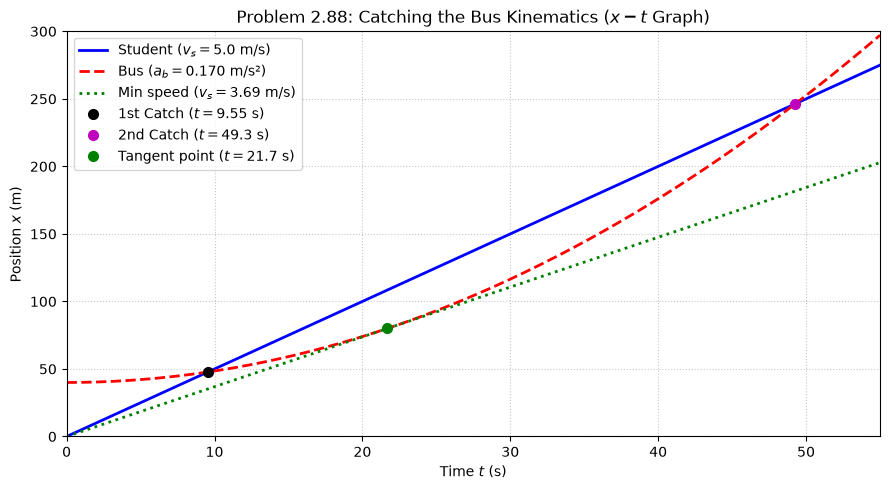

In [ ]:
t_arr = np.linspace(0, 55, 400)

x_student = 5.0 * t_arr
x_bus = 40.0 + 0.5 * 0.170 * t_arr**2
x_student_min = float(v_min_val.value) * t_arr

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(t_arr, x_student, "b-", lw=2, label=r"Student ($v_s = 5.0$ m/s)")
ax.plot(t_arr, x_bus, "r--", lw=2, label=r"Bus ($a_b = 0.170$ m/s²)")
ax.plot(
    t_arr,
    x_student_min,
    "g:",
    lw=2,
    label=rf"Min speed ($v_s = {float(v_min_val.value):.2f}$ m/s)",
)

# Highlight intersection points
ax.plot(
    float(t1.value),
    float(x_meet1.value),
    "ko",
    markersize=7,
    label=f"1st Catch ($t = {float(t1.value):.2f}$ s)",
)
ax.plot(
    float(t2.value),
    5.0 * float(t2.value),
    "mo",
    markersize=7,
    label=f"2nd Catch ($t = {float(t2.value):.1f}$ s)",
)
ax.plot(
    float(t_min_val.value),
    float(x_min_val.value),
    "go",
    markersize=7,
    label=f"Tangent point ($t = {float(t_min_val.value):.1f}$ s)",
)

ax.set_xlabel("Time $t$ (s)")
ax.set_ylabel("Position $x$ (m)")
ax.set_title("Problem 2.88: Catching the Bus Kinematics ($x-t$ Graph)")
ax.set_ylim(0, 300)
ax.set_xlim(0, 55)
ax.grid(True, linestyle=":", alpha=0.7)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

#### 2.89 

••• A ball is thrown straight up from the edge of the roof of a
building. A second ball is dropped from the roof 1.00 s later. Ignore
air resistance. 

**(a)** If the height of the building is 20.0 m, what must the
initial speed of the first ball be if both are to hit the ground at the same
time? 

On the same graph, sketch the positions of both balls as a function
of time, measured from when the first ball is thrown. Consider the
same situation, but now let the initial speed $v_0$ of the first ball be given
and treat the height h of the building as an unknown. 

(b) What must
the height of the building be for both balls to reach the ground at the
same time if 

**(i)** $v_0$ is 6.0 m/s and 

**(ii)** $v_0$ is 9.5 m/s ? 

**(c)** If $v_0$ is greater
than some value $v_{max}, no value of h exists that allows both balls to hit
the ground at the same time. Solve for $v_{max}. The value $v_{max} has a simple
physical interpretation. What is it? 

**(d)** If $v_0$ is less than some value $v_{min},
no value of h exists that allows both balls to hit the ground at the same
time. Solve for $v_{min}. The value $v_{min} also has a simple physical interpretation.
What is it?


In [ ]:
# Symbols
t, v0, g, h = sp.symbols("t v0 g h", real=True, positive=True)

# Positions with ground y=0, +y upward
y1 = h + v0 * t - sp.Rational(1, 2) * g * t**2
y2 = h - sp.Rational(1, 2) * g * (t - 1) ** 2

# Impact condition: y1 = 0 and y2 = 0
# From y2 = 0: h = 1/2 * g * (t - 1)^2
h_expr = sp.Rational(1, 2) * g * (t - 1) ** 2

# Substitute h into y1 = 0
y1_sub = y1.subs(h, h_expr)
v0_sol = sp.solve(sp.Eq(y1_sub, 0), v0)[0]

# Solve for t in terms of v0
t_from_v0 = sp.solve(sp.Eq(v0, v0_sol), t)[0]

# Height equation h(v0)
h_from_v0 = h_expr.subs(t, t_from_v0)

display(
    Math(rf"\text{{Initial velocity equation: }} v_0 = {sp.latex(sp.factor(v0_sol))}")
)
display(Math(rf"\text{{Impact time: }} t = {sp.latex(sp.factor(t_from_v0))}"))
display(Math(rf"\text{{Height equation }} h(v_0) = {sp.latex(sp.factor(h_from_v0))}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
g_val = 9.80

# (a) Initial speed for h = 20.0 m
h_a = 20.0
t_fall = (2 * h_a / g_val) ** 0.5
t_total_a = 1.00 + t_fall
v0_a = g_val - g_val / (2 * t_total_a)


# (b) Height for v0 = 6.0 m/s and 9.5 m/s
def calc_h(v0_val):
    return float(h_from_v0.subs({v0: v0_val, g: g_val}))


h_b1 = calc_h(6.0)
h_b2 = calc_h(9.5)

print(f"(a) For h = 20.0 m: v0 = {v0_a:.2f} m/s (Total time = {t_total_a:.3f} s)")
print(f"(b-i) For v0 = 6.0 m/s: h = {h_b1:.3f} m")
print(f"(b-ii) For v0 = 9.5 m/s: h = {h_b2:.1f} m")
print(f"(c) v_max = 9.80 m/s")
print(f"(d) v_min = 4.90 m/s")

(a) For h = 20.0 m: v0 = 8.18 m/s (Total time = 3.020 s)
(b-i) For v0 = 6.0 m/s: h = 0.411 m
(b-ii) For v0 = 9.5 m/s: h = 1152.0 m
(c) v_max = 9.80 m/s
(d) v_min = 4.90 m/s


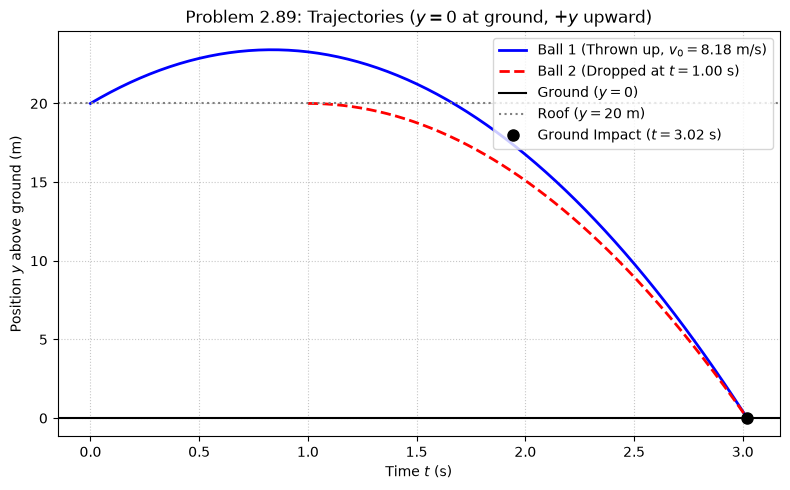

In [ ]:
# Time vector for part (a)
t_arr1 = np.linspace(0, t_total_a, 200)
y1_arr = 20.0 + v0_a * t_arr1 - 0.5 * g_val * t_arr1**2

t_arr2 = np.linspace(1.00, t_total_a, 200)
y2_arr = 20.0 - 0.5 * g_val * (t_arr2 - 1.00) ** 2

plt.figure(figsize=(8, 5))
plt.plot(
    t_arr1, y1_arr, "b-", lw=2, label=f"Ball 1 (Thrown up, $v_0 = {v0_a:.2f}$ m/s)"
)
plt.plot(t_arr2, y2_arr, "r--", lw=2, label="Ball 2 (Dropped at $t = 1.00$ s)")

plt.axhline(0, color="black", lw=1.5, label="Ground ($y = 0$)")
plt.axhline(20, color="gray", linestyle=":", label="Roof ($y = 20$ m)")
plt.plot(
    t_total_a, 0, "ko", markersize=8, label=f"Ground Impact ($t = {t_total_a:.2f}$ s)"
)

plt.xlabel("Time $t$ (s)")
plt.ylabel("Position $y$ above ground (m)")
plt.title("Problem 2.89: Trajectories ($y=0$ at ground, $+y$ upward)")
plt.grid(True, linestyle=":", alpha=0.7)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()